### GOAL: Exploring different concepts related to Data Science.

In [1]:
url = 'https://en.wikipedia.org/wiki/Data_science'

In [2]:
headers = {
    'User-Agent': 'DataScienceLearningBot/1.0 (your-email@example.com)'
}

### 1. Getting the data
Using `requests` library to get this process done.

In [3]:
import requests

In [4]:
response = requests.get(url, headers=headers)
response_text = response.content.decode('utf-8')
#response = requests.get(url).content.decode('utf-8')

In [5]:
# if response.status_code == 200:
#     print("Successfully retrieved!!")
#     print(response.text[:1000])
# else:
#     print(f"Error code: {response.status_code}")

print(response_text[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-

### 2. Transforming the data
- Converting the data into suitable form for processing i.e. converting the HTML text source code to plain text using `HTMLParser`.

In [6]:
from html.parser import HTMLParser

In [7]:
class MyHTMLParser(HTMLParser):
    script = False
    res = ""
    def handle_starttag(self, tag, attrs):
        if tag.lower() in ["script","style"]:
            self.script = True
    def handle_endtag(self, tag):
        if tag.lower() in ["script","style"]:
            self.script = False
    def handle_data(self, data):
        if str.strip(data)=="" or self.script:
            return
        self.res += ' '+data.replace('[ edit ]','')         

In [8]:
parser = MyHTMLParser()
parser.feed(response_text)
response_text = parser.res

In [9]:
print(response_text[:1000])

 Data science - Wikipedia Jump to content Main menu Main menu move to sidebar hide 
		Navigation
	 Main page Contents Current events Random article About Wikipedia Contact us 
		Contribute
	 Help Learn to edit Community portal Recent changes Upload file Special pages Search Search Appearance Donate Create account Log in Personal tools Donate Create account Log in Contents move to sidebar hide (Top) 1 Foundations 2 Etymology Toggle Etymology subsection 2.1 Early usage 2.2 Modern usage 3 Data science and data analysis 4 Cloud computing for data science 5 Ethical consideration in data science 6 See also 7 References Toggle the table of contents Data science 54 languages العربية Azərbaycanca Български বাংলা Català کوردی Čeština Deutsch Ελληνικά Esperanto Español Eesti Euskara فارسی Suomi Français Galego עברית हिन्दी Magyar Հայերեն Bahasa Indonesia Ido Italiano 日本語 Қазақша ಕನ್ನಡ 한국어 Latviešu Македонски Bahasa Melayu မြန်မာဘာသာ Nederlands Norsk bokmål ਪੰਜਾਬੀ Polski Português Runa Simi Русски

### 3. Getting Insights
Using `RAKE` for keyword extraction.
`RAKE` is an unsupervised algorithm used to automatically find the most important keywords and phrases in a body of text.

In [10]:
import nlp_rake

In [11]:
extractor = nlp_rake.Rake(max_words=2, min_freq=3, min_chars= 5)

###### Explanation of the code above
max_words = 2: Limits phrases to a max of two words. Example: "Data Science" or "Algorithms" but no "Machine Learning Algorithms"
max_freq = 3: Words or phrases must appear at least 3 times.
min_chars = 5: Words or phrases must have atleast 5 letters/characters. 

Used specifically to summarize text without requirement of training. 
First the algorithm splits text into sentences and drops words like and, of, the, is.
Second checks which words stand frequently next to each other like Data and Science
Third calculates a score based on how often they appear and how many other words they pair up with. Higher score means phrase is highly relevant to the main topic of text.

In [12]:
result = extractor.apply(response_text)

In [13]:
result

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.893939393939394),
 ('computer science', 3.893939393939394),
 ('information science', 3.8225108225108224),
 ('^ davenport', 3.8),
 ('cloud computing', 3.75),
 ('data analysis', 3.7),
 ('science', 1.893939393939394),
 ('analysis', 1.7),
 ('statistics', 1.2666666666666666),
 ('processing', 1.25),
 ('field', 1.25),
 ('thomas', 1.2),
 ('techniques', 1.0),
 ('education', 1.0),
 ('communications', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]

The result shows a list of terms together with associated degree of importance. 

### Visualization
Using matplotlib library

In [14]:
import matplotlib.pyplot as plt

In [ ]:
def plot(pair_list):
    k, v = zip(*pair_list)

    plt.bar(range(len(k)), v)
    plt.xticks(range(len(k)), k, rotation='vertical')
    plt.show()

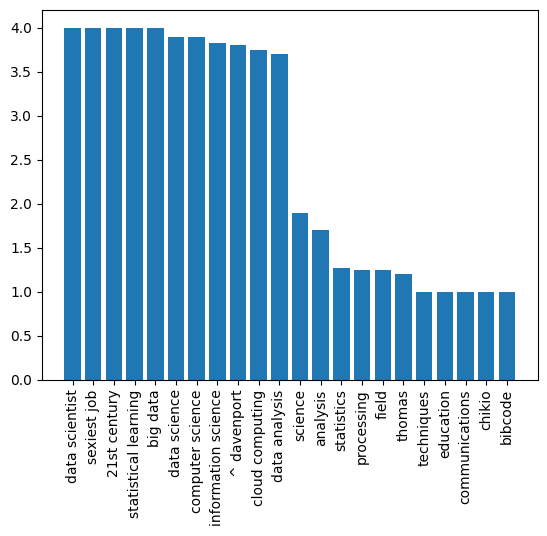

In [20]:
plot(result)

#### Using `WordCloud` instead of barchart
`WordCloud` object is responsible for taking in either the original text, or pre-computed list of words with frequencies and returns image.

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

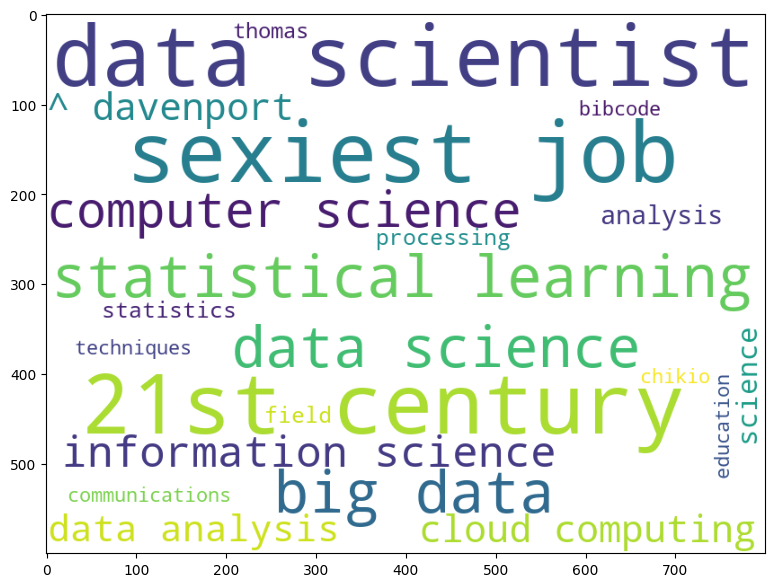

In [22]:
wc = WordCloud(background_color='white', width=800, height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({k:v for k, v in result}))

#### Using the original scraped text

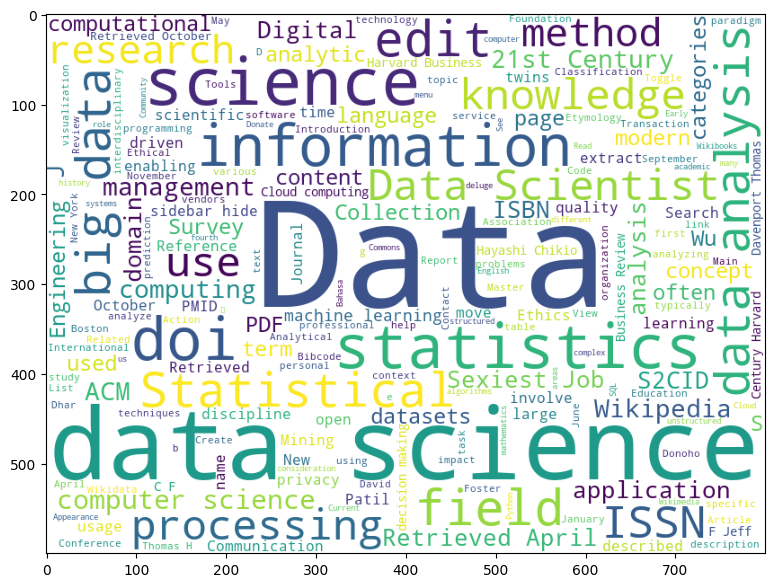

In [23]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(response_text))

In [26]:
# Save as file
wc.generate(response_text).to_file('../images/ds_wordcloud.png')

Comparing the two outputs, the first one with RAKE is cleaner as it does better job at selecting good keywords from the text. The second image has a lot of noise. This is an illustration of data pre-processing and cleaning using RAKE. 